## **Pose Estimation**

In [12]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
# Suppress specific OpenCV DNN warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow logging (used by OpenCV DNN)

class PoseEstimator:
    def __init__(self, model_path="graph_opt.pb"):
        # MediaPipe Pose Setup
        self.mp_pose = mp.solutions.pose
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_drawing_styles = mp.solutions.drawing_styles
        
        # Increase detection confidence threshold for better results
        self.mp_pose_model = self.mp_pose.Pose(
            static_image_mode=True,  # For image processing
            model_complexity=2,  # Use the most accurate model
            enable_segmentation=True,  # Enable segmentation for better isolation
            min_detection_confidence=0.7,
            min_tracking_confidence=0.7
        )

        # OpenPose Setup using OpenCV DNN
        try:
            self.net = cv2.dnn.readNetFromTensorflow(model_path)
        except Exception as e:
            warnings.warn(f"Could not load OpenPose model from {model_path}. Error: {e}")
            self.net = None
            
        self.inWidth = 368
        self.inHeight = 368
        self.threshold = 0.2  # Confidence threshold for keypoint detection
        
        # Define body parts and connections for OpenPose
        self.BODY_PARTS = {
            "Nose": 0, "Neck": 1, "RShoulder": 2, "RElbow": 3, "RWrist": 4,
            "LShoulder": 5, "LElbow": 6, "LWrist": 7, "RHip": 8, "RKnee": 9,
            "RAnkle": 10, "LHip": 11, "LKnee": 12, "LAnkle": 13, "REye": 14,
            "LEye": 15, "REar": 16, "LEar": 17, "Background": 18
        }
        
        self.POSE_PAIRS = [
            ["Neck", "RShoulder"], ["Neck", "LShoulder"], ["RShoulder", "RElbow"],
            ["RElbow", "RWrist"], ["LShoulder", "LElbow"], ["LElbow", "LWrist"],
            ["Neck", "RHip"], ["RHip", "RKnee"], ["RKnee", "RAnkle"], ["Neck", "LHip"],
            ["LHip", "LKnee"], ["LKnee", "LAnkle"], ["Neck", "Nose"], ["Nose", "REye"],
            ["REye", "REar"], ["Nose", "LEye"], ["LEye", "LEar"]
        ]

    def estimate_mediapipe_pose(self, image):
        """
        Estimate pose using MediaPipe
        """
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Process the image and find poses
        results = self.mp_pose_model.process(image_rgb)
        
        # Draw pose landmarks
        output_image = image.copy()
        if results.pose_landmarks:
            # Draw the pose landmarks on the image with enhanced visibility
            self.mp_drawing.draw_landmarks(
                output_image,
                results.pose_landmarks,
                self.mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=self.mp_drawing.DrawingSpec(
                    color=(0, 255, 0), thickness=4, circle_radius=6),
                connection_drawing_spec=self.mp_drawing.DrawingSpec(
                    color=(255, 0, 0), thickness=4)
            )
        
        return output_image, results.pose_landmarks

    def estimate_openpose(self, image):
        """
        Estimate pose using OpenPose model via OpenCV DNN
        """
        frameWidth = image.shape[1]
        frameHeight = image.shape[0]
        
        # Prepare input blob and run inference
        self.net.setInput(cv2.dnn.blobFromImage(
            image, 
            1.0, 
            (self.inWidth, self.inHeight), 
            (127.5, 127.5, 127.5), 
            swapRB=True, 
            crop=False
        ))
        
        out = self.net.forward()
        out = out[:, :19, :, :]  # MobileNet output [1, 57, -1, -1], we only need the first 19 elements
        
        # Find pose points
        points = []
        for i in range(len(self.BODY_PARTS)):
            # Slice heatmap of corresponging body's part
            heatMap = out[0, i, :, :]
            
            # Find global maximum
            _, conf, _, point = cv2.minMaxLoc(heatMap)
            
            x = (frameWidth * point[0]) / out.shape[3]
            y = (frameHeight * point[1]) / out.shape[2]
            
            # Add a point if its confidence is higher than threshold
            points.append((int(x), int(y)) if conf > self.threshold else None)
        
        # Draw pose
        output_image = image.copy()
        for pair in self.POSE_PAIRS:
            partFrom = pair[0]
            partTo = pair[1]
            
            idFrom = self.BODY_PARTS[partFrom]
            idTo = self.BODY_PARTS[partTo]
            
            if points[idFrom] and points[idTo]:
                # Draw thicker, more visible lines and larger points
                cv2.line(output_image, points[idFrom], points[idTo], (0, 0, 255), 4)
                cv2.circle(output_image, points[idFrom], 8, (0, 255, 0), thickness=-1)
                cv2.circle(output_image, points[idTo], 8, (0, 255, 0), thickness=-1)
        
        return output_image, points

    def predict_exercise(self, landmarks):
        """
        Predict exercise type based on pose landmarks
        """
        if not landmarks:
            return "No pose detected"
        
        # Simple exercise classification logic
        def is_squat(landmarks):
            hip_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_HIP].y
            knee_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_KNEE].y
            ankle_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_ANKLE].y
            return knee_y < hip_y  # Knees bent below hip level

        def is_pushup(landmarks):
            shoulder_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_SHOULDER].y
            elbow_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_ELBOW].y
            wrist_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_WRIST].y
            return elbow_y > shoulder_y  # Elbow below shoulder

        def is_jumping_jack(landmarks):
            left_wrist = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_WRIST]
            right_wrist = landmarks.landmark[self.mp_pose.PoseLandmark.RIGHT_WRIST]
            return left_wrist.y < left_wrist.y and right_wrist.y < right_wrist.y

        def is_arm_raise(landmarks):
            shoulder_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_SHOULDER].y
            wrist_y = landmarks.landmark[self.mp_pose.PoseLandmark.LEFT_WRIST].y
            return wrist_y < shoulder_y  # Arm raised above shoulder

        # Check each exercise
        if is_squat(landmarks):
            return "Squat"
        elif is_pushup(landmarks):
            return "Push-up"
        elif is_jumping_jack(landmarks):
            return "Jumping Jack"
        elif is_arm_raise(landmarks):
            return "Arm Raise"
        
        return "Unknown Exercise"
    
    def predict_exercise_from_openpose(self, points):
        """
        Predict exercise type based on OpenPose points
        """
        if not points or points.count(None) > 10:  # If too many points are missing
            return "No pose detected"
        
        # Map OpenPose indices to body parts
        neck = points[self.BODY_PARTS["Neck"]]
        left_shoulder = points[self.BODY_PARTS["LShoulder"]]
        right_shoulder = points[self.BODY_PARTS["RShoulder"]]
        left_elbow = points[self.BODY_PARTS["LElbow"]]
        right_elbow = points[self.BODY_PARTS["RElbow"]]
        left_wrist = points[self.BODY_PARTS["LWrist"]]
        right_wrist = points[self.BODY_PARTS["RWrist"]]
        left_hip = points[self.BODY_PARTS["LHip"]]
        right_hip = points[self.BODY_PARTS["RHip"]]
        left_knee = points[self.BODY_PARTS["LKnee"]]
        right_knee = points[self.BODY_PARTS["RKnee"]]
        left_ankle = points[self.BODY_PARTS["LAnkle"]]
        right_ankle = points[self.BODY_PARTS["RAnkle"]]
        
        # Simple exercise classification
        if left_knee and left_hip and right_knee and right_hip:
            # Check for squat - knees bent, hips lower than normal standing position
            if left_knee[1] > left_hip[1] and right_knee[1] > right_hip[1]:
                return "Squat"
        
        if left_shoulder and left_elbow and right_shoulder and right_elbow:
            # Check for pushup - elbows bent, body horizontal
            if (left_elbow[1] > left_shoulder[1] and right_elbow[1] > right_shoulder[1] and
                abs(left_shoulder[1] - right_shoulder[1]) < 30):  # Shoulders roughly at same height
                return "Push-up"
        
        if left_shoulder and left_wrist and right_shoulder and right_wrist:
            # Check for jumping jack - arms raised above shoulders
            if (left_wrist[1] < left_shoulder[1] and right_wrist[1] < right_shoulder[1] and
                left_wrist[0] < left_shoulder[0] and right_wrist[0] > right_shoulder[0]):
                return "Jumping Jack"
            
            # Check for arm raise - arms extended above shoulders
            if left_wrist[1] < left_shoulder[1] and right_wrist[1] < right_shoulder[1]:
                return "Arm Raise"
        
        return "Unknown Exercise"

    def process_image(self, image_path):
        """
        Process the input image with both pose estimation models
        """
        # Read the image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not read image from {image_path}")
        
        # MediaPipe Pose Estimation
        mediapipe_image, mediapipe_landmarks = self.estimate_mediapipe_pose(image.copy())
        mediapipe_prediction = "No pose detected"
        if mediapipe_landmarks:
            mediapipe_prediction = self.predict_exercise(mediapipe_landmarks)
        
        # OpenPose Estimation
        openpose_image, openpose_points = self.estimate_openpose(image.copy())
        openpose_prediction = self.predict_exercise_from_openpose(openpose_points)
        
        # Get model performance info
        t, _ = self.net.getPerfProfile()
        freq = cv2.getTickFrequency() / 1000
        performance_ms = t / freq
        
        
        # Plot results
        plt.figure(figsize=(16,6))
        
        # MediaPipe Subplot
        plt.subplot(1, 2, 1)
        plt.title(f'MediaPipe Pose\nPredicted Exercise: {mediapipe_prediction}', fontsize=12, fontweight='bold')
        plt.imshow(cv2.cvtColor(mediapipe_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        # OpenPose Subplot
        plt.subplot(1, 2, 2)
        plt.title(f'OpenPose\nPredicted Exercise: {openpose_prediction}', fontsize=12, fontweight='bold')
        plt.imshow(cv2.cvtColor(openpose_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        
        plt.tight_layout()
        
        # Disable matplotlib warnings during display
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            plt.show()
        
        return {
            'MediaPipe': {
                'Exercise Prediction': mediapipe_prediction,
                'Landmarks': mediapipe_landmarks
            },
            'OpenPose': {
                'Exercise Prediction': openpose_prediction,
                'Points': openpose_points,
                'Performance': f'{performance_ms:.2f}ms'
            }
        }


### **Arm Rise**

W0000 00:00:1747068329.503220     179 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747068329.717234     179 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


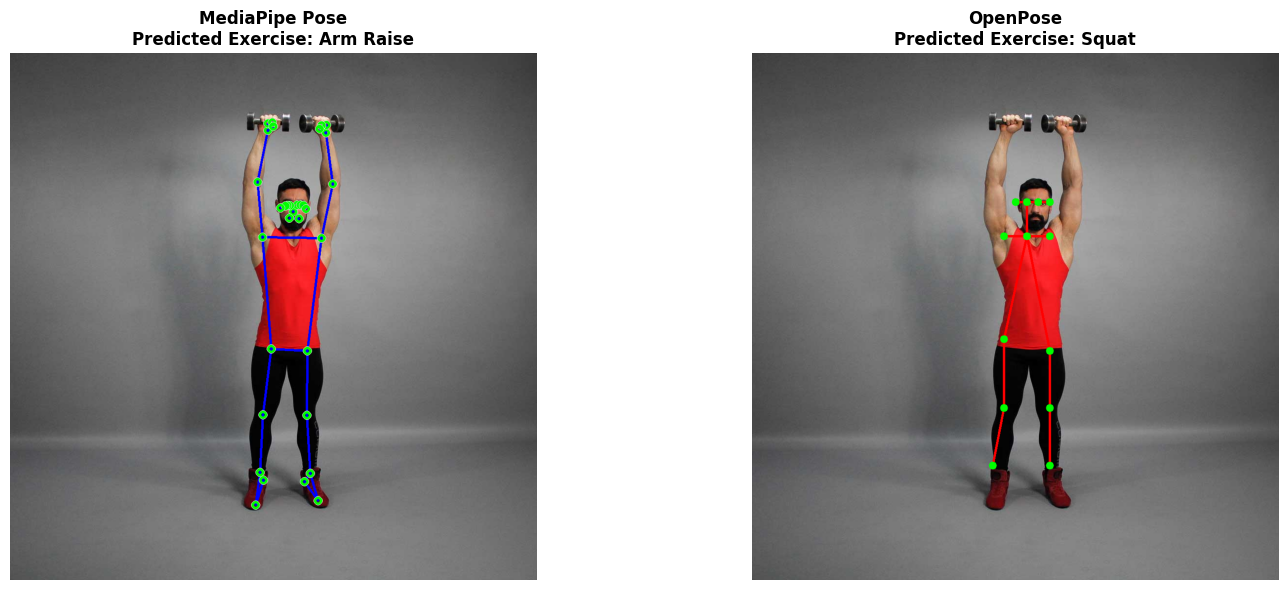


RESULTS:
-------------------
MediaPipe Prediction: Arm Raise
OpenPose Prediction: Squat
OpenPose Performance: 173.04ms
-------------------


In [ ]:
if __name__ == "__main__":
    # Suppress all warnings during execution
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Path to your input image
        input_image_path = 'ARM Rise 2.jpg'  # Change to your image path
        
        # Path to the OpenPose model
        model_path = "graph_opt.pb"  # Change to your model path
        
        # Initialize pose estimator
        pose_estimator = PoseEstimator(model_path)
        
        # Process the image
        try:
            results = pose_estimator.process_image(input_image_path)
            
            # Print results
            print("\nRESULTS:")
            print("-------------------")
            print("MediaPipe Prediction:", results['MediaPipe']['Exercise Prediction'])
            print("OpenPose Prediction:", results['OpenPose']['Exercise Prediction'])
            print("OpenPose Performance:", results['OpenPose']['Performance'])
            print("-------------------")
        except Exception as e:
            print(f"Error processing image: {e}")

### **Jumping Jacks**

W0000 00:00:1747067996.605442     159 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747067996.830399     161 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


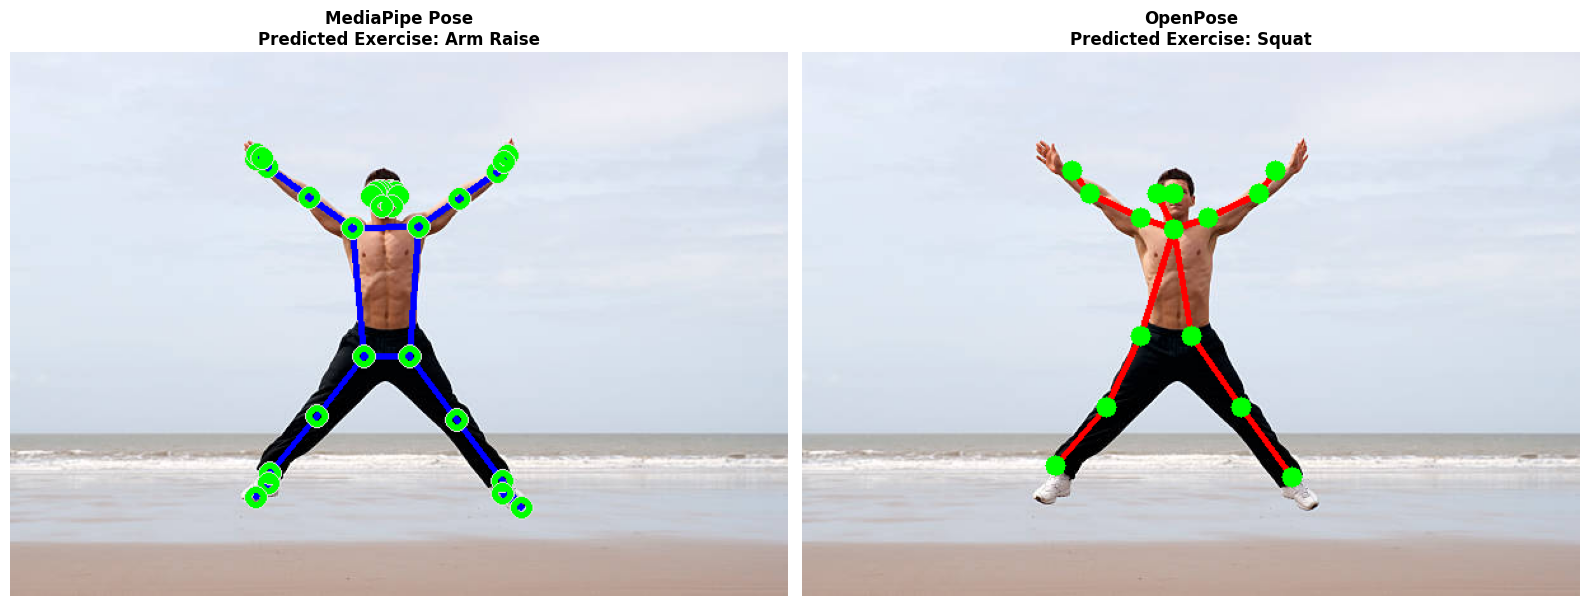


RESULTS:
-------------------
MediaPipe Prediction: Arm Raise
OpenPose Prediction: Squat
OpenPose Performance: 114.90ms
-------------------


In [ ]:
if __name__ == "__main__":
    # Suppress all warnings during execution
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Path to your input image
        input_image_path = 'Jumping-Jacks.jpg'  # Change to your image path
        
        # Path to the OpenPose model
        model_path = "graph_opt.pb"  # Change to your model path
        
        # Initialize pose estimator
        pose_estimator = PoseEstimator(model_path)
        
        # Process the image
        try:
            results = pose_estimator.process_image(input_image_path)
            
            # Print results
            print("\nRESULTS:")
            print("-------------------")
            print("MediaPipe Prediction:", results['MediaPipe']['Exercise Prediction'])
            print("OpenPose Prediction:", results['OpenPose']['Exercise Prediction'])
            print("OpenPose Performance:", results['OpenPose']['Performance'])
            print("-------------------")
        except Exception as e:
            print(f"Error processing image: {e}")

### **Push-Ups**

W0000 00:00:1747068449.185152     184 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747068449.404350     184 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


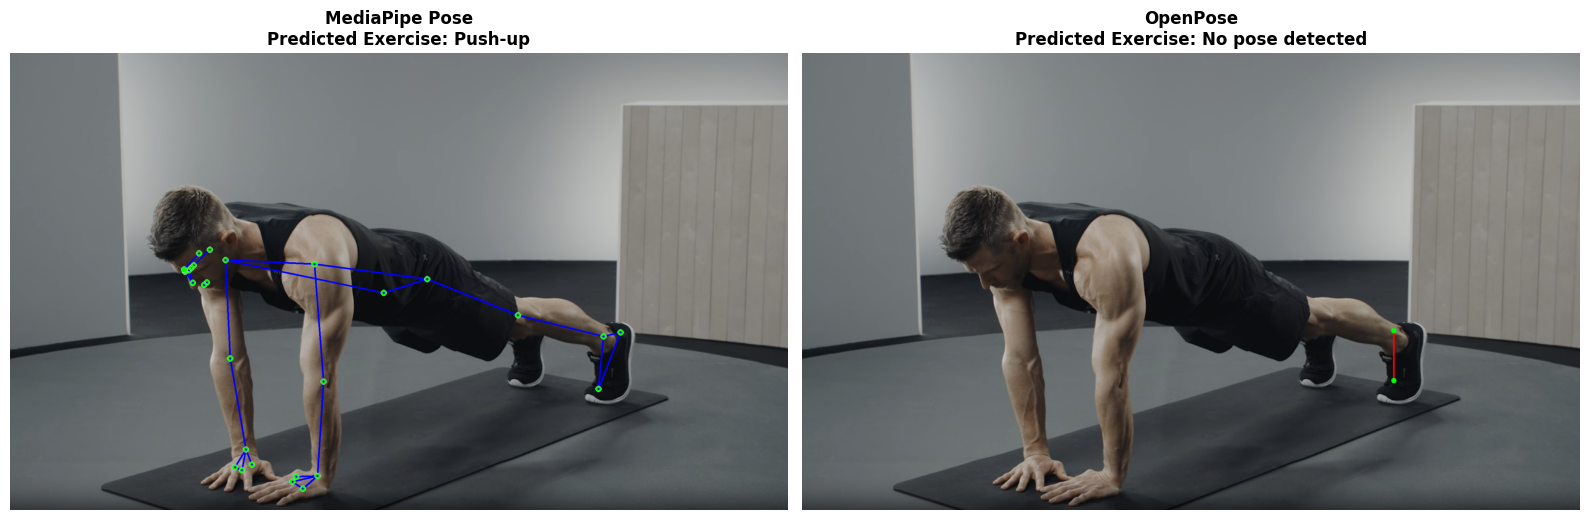


RESULTS:
-------------------
MediaPipe Prediction: Push-up
OpenPose Prediction: No pose detected
OpenPose Performance: 222.76ms
-------------------


In [ ]:
if __name__ == "__main__":
    # Suppress all warnings during execution
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Path to your input image
        input_image_path = 'push up.png'  # Change to your image path
        
        # Path to the OpenPose model
        model_path = "graph_opt.pb"  # Change to your model path
        
        # Initialize pose estimator
        pose_estimator = PoseEstimator(model_path)
        
        # Process the image
        try:
            results = pose_estimator.process_image(input_image_path)
            
            # Print results
            print("\nRESULTS:")
            print("-------------------")
            print("MediaPipe Prediction:", results['MediaPipe']['Exercise Prediction'])
            print("OpenPose Prediction:", results['OpenPose']['Exercise Prediction'])
            print("OpenPose Performance:", results['OpenPose']['Performance'])
            print("-------------------")
        except Exception as e:
            print(f"Error processing image: {e}")

### **Squats**

W0000 00:00:1747068555.206133     189 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747068555.405453     189 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


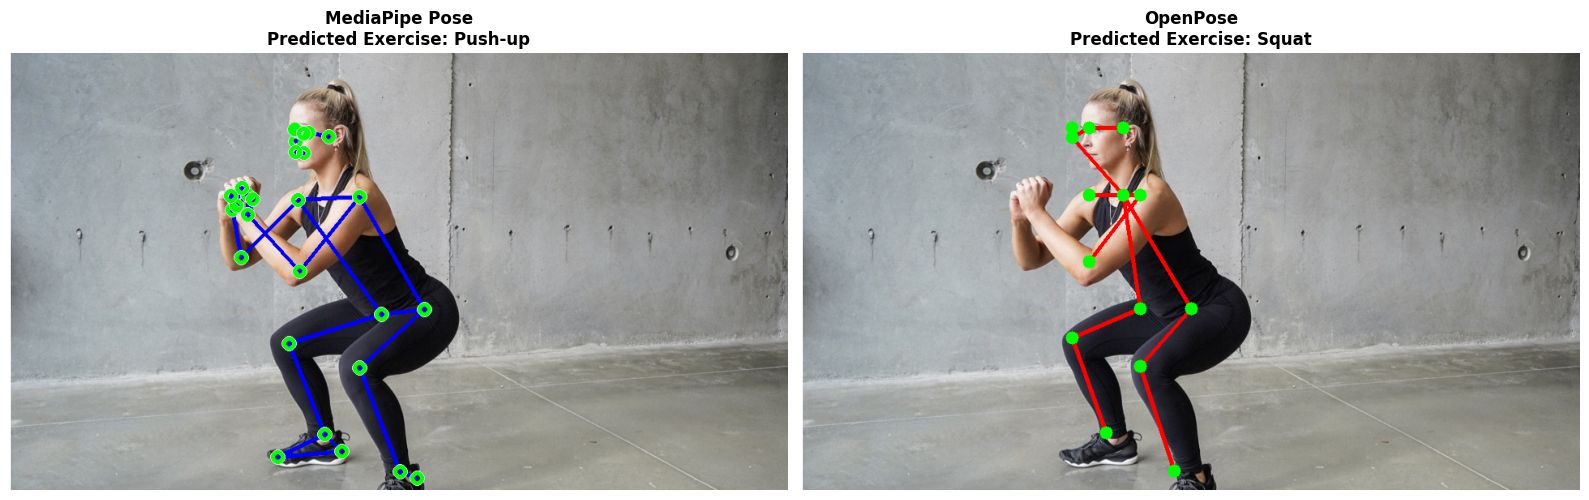


RESULTS:
-------------------
MediaPipe Prediction: Push-up
OpenPose Prediction: Squat
OpenPose Performance: 119.08ms
-------------------


In [ ]:
if __name__ == "__main__":
    # Suppress all warnings during execution
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Path to your input image
        input_image_path = 'squat-jumps-960x540.jpg'  # Change to your image path
        
        # Path to the OpenPose model
        model_path = "graph_opt.pb"  # Change to your model path
        
        # Initialize pose estimator
        pose_estimator = PoseEstimator(model_path)
        
        # Process the image
        try:
            results = pose_estimator.process_image(input_image_path)
            
            # Print results
            print("\nRESULTS:")
            print("-------------------")
            print("MediaPipe Prediction:", results['MediaPipe']['Exercise Prediction'])
            print("OpenPose Prediction:", results['OpenPose']['Exercise Prediction'])
            print("OpenPose Performance:", results['OpenPose']['Performance'])
            print("-------------------")
        except Exception as e:
            print(f"Error processing image: {e}")

### **Research Papers**

1. **Realtime Multi-Person 2D Pose Estimation Using Part Affinity Fields**  
   - **Link**: [View Paper](https://openaccess.thecvf.com/content_cvpr_2017/papers/Cao_Realtime_Multi-Person_2D_CVPR_2017_paper.pdf)

2. **BlazePose: On-device Real-time Body Pose Tracking**  
   - **Link**: [View Paper](https://arxiv.org/pdf/2006.10204)


### **Datasets for Pose Estimation**

Several datasets are widely used for training and evaluating pose estimation models. Below are some of the most prominent ones, along with detailed descriptions and considerations for selection:


#### 1. **COCO Keypoints Dataset**
- **Description**: The COCO (Common Objects in Context) Keypoints dataset provides labeled data for 17 keypoints on the human body, including joints like shoulders, elbows, and knees. It is extensively used for training and evaluating human pose estimation models.
- **Dataset Highlights**:
  - Contains over 200,000 labeled keypoints.
  - Offers annotations for multiple persons in a single image.
  - Diverse set of poses in complex backgrounds.
- **Link**: [COCO Keypoints Dataset](https://cocodataset.org/#keypoints-2020)

#### 2. **MPII Human Pose Dataset**
- **Description**: The MPII (Max Planck Institute for Informatics) Human Pose dataset is curated for human pose estimation, focusing on everyday activities. It provides detailed annotations of body joints and activities.
- **Dataset Highlights**:
  - Includes over 40,000 annotated images.
  - High variation in poses, clothing, and environments.
  - Annotations include both 2D keypoints and activity labels.
- **Link**: [MPII Human Pose Dataset](http://human-pose.mpi-inf.mpg.de/)

#### 3. **Human3.6M Dataset**
- **Description**: The Human3.6M dataset is a large-scale dataset for 3D human pose estimation. It features subjects performing diverse activities in a controlled environment, captured using a multi-camera system.
- **Dataset Highlights**:
  - Contains 3.6 million 3D human poses.
  - Includes synchronized RGB and depth images.
  - Ideal for research on 3D pose estimation and motion analysis.
- **Link**: [Human3.6M Dataset](http://vision.imar.ro/human3.6m/description.php)

#### 4. **BlazePose Dataset**
- **Description**: Developed by Google Research, the BlazePose dataset powers on-device, real-time pose tracking. It is optimized for mobile and edge devices and focuses on full-body landmark detection.
- **Dataset Highlights**:
  - Provides annotations for 33 body keypoints.
  - Specifically designed for lightweight models on mobile devices.
  - Balanced for diverse user poses and demographics.
- **Link**: [BlazePose Dataset](https://github.com/google/mediapipe/blob/master/mediapipe/python/solutions/pose.md#resources)


---

### **Selection Criteria for Dataset**

The choice of dataset depends on several factors, including the model's intended application, the required level of detail, and computational constraints. Below are the selection criteria for choosing a dataset:

1. **Task Type**:
   - **Single-Person Pose Estimation**: MPII Human Pose or LSP is ideal for tasks involving one person in the frame.
   - **Multi-Person Pose Estimation**: COCO or PoseTrack is preferred due to its crowd annotations and diverse poses.

2. **Application Context**:
   - **Real-Time Edge Devices**: BlazePose dataset is best for lightweight, on-device applications.
   - **Sports and Motion Analysis**: LSP is suitable for detailed sports-oriented motion analysis.

3. **Model Complexity**:
   - High-complexity models can benefit from COCO or PoseTrack due to their large size and diversity.
   - Lightweight models may prefer BlazePose or MPII to reduce training overhead.

4. **Annotation Granularity**:
   - For tasks requiring fine-grained pose tracking, PoseTrack or BlazePose datasets provide detailed annotations.
   - For simpler tasks, MPII or LSP suffices.

5. **Availability and Licensing**:
   - Public datasets like COCO and MPII are preferred for open research due to accessibility.
   - Proprietary datasets like BlazePose may offer better real-time performance but are restricted in availability.

---

### **Selected Dataset**
For the proposed project focusing on **real-time multi-person pose estimation**, the **COCO dataset** is selected due to its:
   - High diversity in human poses and environments.
   - Comprehensive annotations for 17 keypoints, supporting advanced models like OpenPose.
   - Wide acceptance and benchmarking in the pose estimation community.

The COCO dataset ensures robust training and testing, enabling the model to handle real-world challenges like occlusion and varied lighting conditions.


---

### **Selection Criteria for Dataset**

The choice of dataset depends on several factors, including the model's intended application, the required level of detail, and computational constraints. Below are the selection criteria for choosing a dataset:

1. **Task Type**:
   - **Single-Person Pose Estimation**: MPII Human Pose or LSP is ideal for tasks involving one person in the frame.
   - **Multi-Person Pose Estimation**: COCO or PoseTrack is preferred due to its crowd annotations and diverse poses.

2. **Application Context**:
   - **Real-Time Edge Devices**: BlazePose dataset is best for lightweight, on-device applications.
   - **Sports and Motion Analysis**: LSP is suitable for detailed sports-oriented motion analysis.

3. **Model Complexity**:
   - High-complexity models can benefit from COCO or PoseTrack due to their large size and diversity.
   - Lightweight models may prefer BlazePose or MPII to reduce training overhead.

4. **Annotation Granularity**:
   - For tasks requiring fine-grained pose tracking, PoseTrack or BlazePose datasets provide detailed annotations.
   - For simpler tasks, MPII or LSP suffices.

5. **Availability and Licensing**:
   - Public datasets like COCO and MPII are preferred for open research due to accessibility.
   - Proprietary datasets like BlazePose may offer better real-time performance but are restricted in availability.

---

### **Selected Dataset**
For the proposed project focusing on **real-time multi-person pose estimation**, the **COCO dataset** is selected due to its:
   - High diversity in human poses and environments.
   - Comprehensive annotations for 17 keypoints, supporting advanced models like OpenPose.
   - Wide acceptance and benchmarking in the pose estimation community.

The COCO dataset ensures better training and testing, enabling the model to handle real-world challenges like occlusion and varied lighting conditions.
